In [27]:
import matplotlib.pyplot as plt
import numpy as np

import sys
sys.path.append('../')
from src.option import Option

In [26]:
import importlib
importlib.reload(sys.modules['src.option'])

<module 'src.option' from 'c:\\Users\\wfpin\\Desktop\\Projects\\greeks\\notebooks\\..\\src\\option.py'>

In [29]:
S = 100; T = 5; r = 0.02; K = 100; sigma = 0.3
opt0 = Option(S, T, r, K, sigma)
market_price = opt0.black_scholes()
iv_bisection = opt0.implied_vol_bisection(market_price=market_price)
iv_newton = opt0.implied_vol_newton(market_price=market_price)
print(f'Implied volatility as estimated by the bisection method: {iv_bisection}')
print(f'Implied volatility as estimated by the Newton-Raphson method: {iv_newton}')
print(f'True implied volatility value: {opt0.sigma}')

Implied volatility as estimated by the bisection method: 0.3000000019720905
Implied volatility as estimated by the Newton-Raphson method: 0.29999999999999954
True implied volatility value: 0.3


In [30]:
iv_newton = opt0.implied_vol_newton(market_price=market_price, initial_guess=0.01)
print(f'Implied volatility as estimated by the Newton-Raphson method: {iv_newton}')

Implied volatility as estimated by the Newton-Raphson method: 5328.751737300914


The output from the last 2 cells is interesting because it highlights one of the weaknesses of the $Newton$-$Raphson$ method. It requires a relatively local guess of what the true implied volatility is. Otherwise, the method makes too large of a jump and completely misses the true value. This explains why, in practice, some combination of the 2 is used where the $Newton$-$Raphson$ method is used if its guess falls within some safe bound and defaults to the bisection method if necessary.

The following plot highlights the difference in efficiency. The $Newton$-$Raphson$ method cut off, the method clearly converged to the true value before the bisection method was able to. It not only cut off sooner, indicating that the difference in values fell within the acceptable tolerance sooner, but it also made predictions closer to the true value quicker.

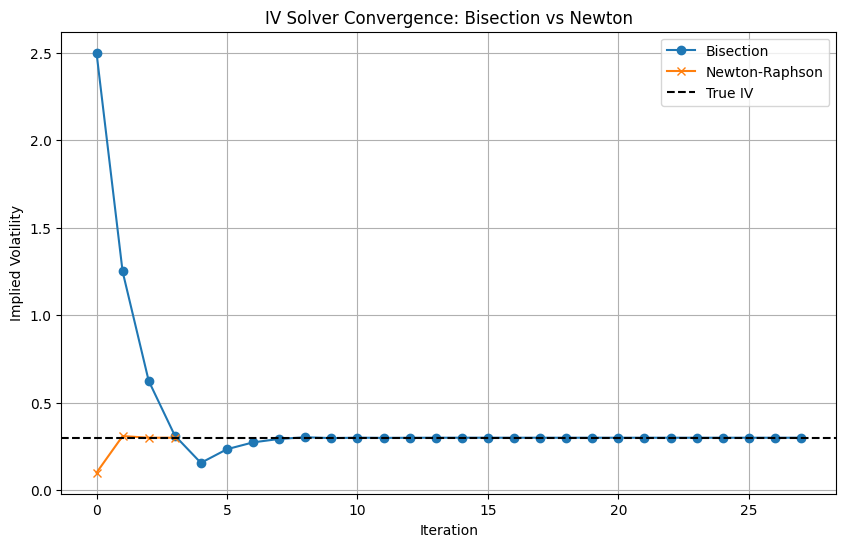

In [31]:
def plot_iv_convergence(option, market_price):

    bis_path = option.implied_vol_bisection(
        market_price, return_path=True
    )

    newton_path = option.implied_vol_newton(
        market_price, initial_guess=0.1, return_path=True
    )

    true_iv = option.sigma

    plt.figure(figsize=(10,6))

    # iteration indices
    plt.plot(bis_path, label="Bisection", marker='o')
    plt.plot(newton_path, label="Newton-Raphson", marker='x')

    # true value line
    plt.axhline(true_iv, linestyle='--', color='black', label="True IV")

    plt.xlabel("Iteration")
    plt.ylabel("Implied Volatility")
    plt.title("IV Solver Convergence: Bisection vs Newton")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_iv_convergence(option=opt0, market_price=market_price)